# Exploratory Data Analysis (EDA) of Netflix Movies and TV Shows

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset to identify patterns, trends, and meaningful insights through data cleaning, preprocessing, and visualization.

# Step 1: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Step 2: Load the Dataset

In [4]:
df = pd.read_csv("netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8149,s8150,Movie,Tamanchey,Navneet Behal,"Nikhil Dwivedi, Richa Chadha, Damandeep Singh ...",India,"October 15, 2017",2014,TV-MA,111 min,"Action & Adventure, International Movies, Roma...",A man and a woman on the run from the law are ...
8150,s8151,Movie,Tarif de nuit,Julien Seri,"Jonathan Howard, Jonathan Demurger, Fanny Vale...",France,"March 1, 2018",2015,TV-MA,81 min,"International Movies, Thrillers",A night out in Paris quickly unravels when two...
8151,s8152,Movie,Tarzan,"Chris Buck, Kevin Lima","Tony Goldwyn, Minnie Driver, Glenn Close, Bria...",United States,"June 23, 2018",1999,G,89 min,Children & Family Movies,"After being shipwrecked off the African coast,..."
8152,s8153,Movie,Tarzan 2,Brian Smith,"Harrison Chad, George Carlin, Brad Garrett, Ro...",United States,"June 23, 2017",2005,G,72 min,Children & Family Movies,How did the King of the Jungle ascend to the t...
8153,s8154,Movie,Tattah,Sameh Abdulaziz,"Mohamed Saad, Dolly Shahin, Marwa, Hayatem, Sa...",Egypt,"May 9, 2019",2013,TV-14,NaN,NaN,NaN


In [7]:
df.shape

(8154, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8154 entries, 0 to 8153
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8154 non-null   object
 1   type          8154 non-null   object
 2   title         8154 non-null   object
 3   director      5636 non-null   object
 4   cast          7407 non-null   object
 5   country       7351 non-null   object
 6   date_added    8145 non-null   object
 7   release_year  8154 non-null   int64 
 8   rating        8150 non-null   object
 9   duration      8150 non-null   object
 10  listed_in     8153 non-null   object
 11  description   8153 non-null   object
dtypes: int64(1), object(11)
memory usage: 764.6+ KB


In [10]:
df.describe()

,release_year
count,8154.000000
mean,2014.503066
std,8.411897
min,1925.000000
25%,2014.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8154,8154,8154,5636,7407,7351,8145,8154.000000,8150,8150,8153,8153
unique,8154,2,8154,4188,7129,684,1700,NaN,17,216,501,8123
top,s8154,Movie,Tattah,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Stand-Up Comedy,"Paranormal activity at a lush, abandoned prope..."
freq,1,5597,1,19,16,2571,79,NaN,3051,1715,334,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.503066,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.411897,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2518
cast,747
country,803
date_added,9
release_year,0
rating,4
duration,4


# Step 3: Data Cleaning

In [13]:
missing = (df.isnull().sum() / len(df)) * 100

missing.sort_values(ascending=False)

,0
director,30.880549
country,9.847927
cast,9.161148
date_added,0.110375
duration,0.049056
rating,0.049056
description,0.012264
listed_in,0.012264
title,0.000000
type,0.000000


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['director'] = df['director'].fillna('Unknown')

In [16]:
df['cast'] = df['cast'].fillna('Not Available')

In [17]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [18]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [19]:
df['date_added'] = df['date_added'].fillna('Unknown')

In [20]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,4


In [21]:
df.rename(columns={
    'listed_in':'genre'
}, inplace=True)

In [22]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

In [23]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [24]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8154 entries, 0 to 8153
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8154 non-null   object        
 1   type          8154 non-null   object        
 2   title         8154 non-null   object        
 3   director      8154 non-null   object        
 4   cast          8154 non-null   object        
 5   country       8154 non-null   object        
 6   date_added    8077 non-null   datetime64[ns]
 7   release_year  8154 non-null   int64         
 8   rating        8154 non-null   object        
 9   duration      8150 non-null   object        
 10  genre         8153 non-null   object        
 11  description   8153 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 764.6+ KB


In [26]:
df.drop('description', axis=1, inplace=True)

In [27]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [28]:
df.shape

(8154, 11)

In [29]:
df.to_csv("cleaned_netflix_titles.csv", index=False)

# Step 4: Data Preprocessing

In [30]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [31]:
df['year_added'] = df['date_added'].dt.year

In [32]:
df[['date_added','year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [33]:
df['month_added'] = df['date_added'].dt.month_name()

In [34]:
df[['date_added','month_added']].head()

,date_added,month_added
0,2021-09-25,September
1,2021-09-24,September
2,2021-09-24,September
3,2021-09-24,September
4,2021-09-24,September


In [35]:
df['duration'].unique()[:20]

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min'], dtype=object)

In [36]:
df['duration_num'] = df['duration'].str.extract('(\d+)')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2612/329591039.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)')


In [37]:
df['duration_num'] = pd.to_numeric(df['duration_num'])

In [38]:
df[['duration','duration_num']].head()

,duration,duration_num
0,90 min,90.0
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0


In [39]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,77
release_year,0
rating,0
duration,4


In [40]:
df['year_added'] = df['year_added'].fillna(0)
df['month_added'] = df['month_added'].fillna('Unknown')

In [41]:
df['year_added'] = df['year_added'].astype(int)

In [42]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,year_added,month_added,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,September,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021,September,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,September,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021,September,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021,September,2.0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8154 entries, 0 to 8153
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8154 non-null   object        
 1   type          8154 non-null   object        
 2   title         8154 non-null   object        
 3   director      8154 non-null   object        
 4   cast          8154 non-null   object        
 5   country       8154 non-null   object        
 6   date_added    8077 non-null   datetime64[ns]
 7   release_year  8154 non-null   int64         
 8   rating        8154 non-null   object        
 9   duration      8150 non-null   object        
 10  genre         8153 non-null   object        
 11  year_added    8154 non-null   int64         
 12  month_added   8154 non-null   object        
 13  duration_num  8150 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(10)
memory usage: 892.0+ KB


In [44]:
df.shape

(8154, 14)

# Step 5: Exploratory Data Analysis (EDA)

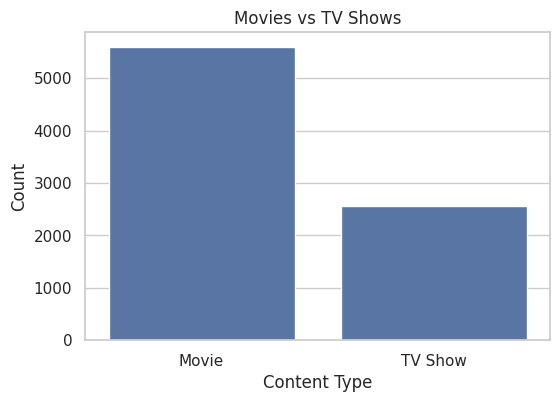

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows')

plt.xlabel('Content Type')

plt.ylabel('Count')

plt.show()

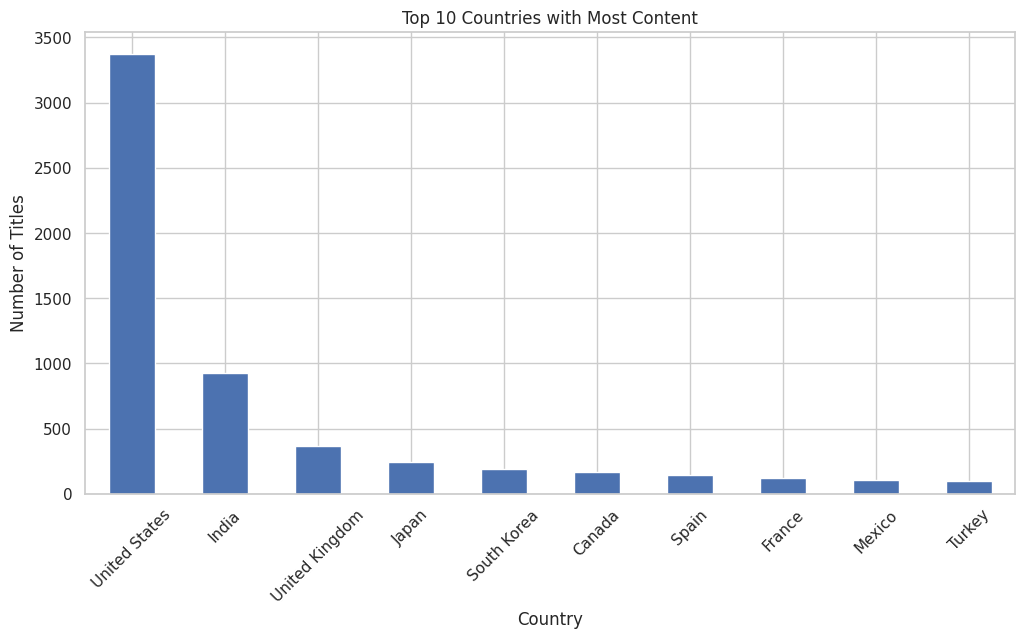

In [46]:
plt.figure(figsize=(12,6))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries with Most Content')

plt.xlabel('Country')

plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

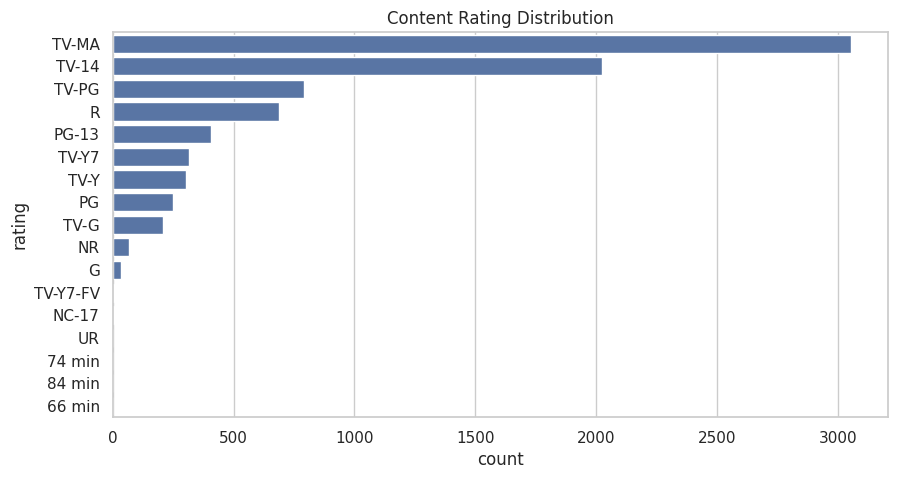

In [47]:
plt.figure(figsize=(10,5))

sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title('Content Rating Distribution')

plt.show()

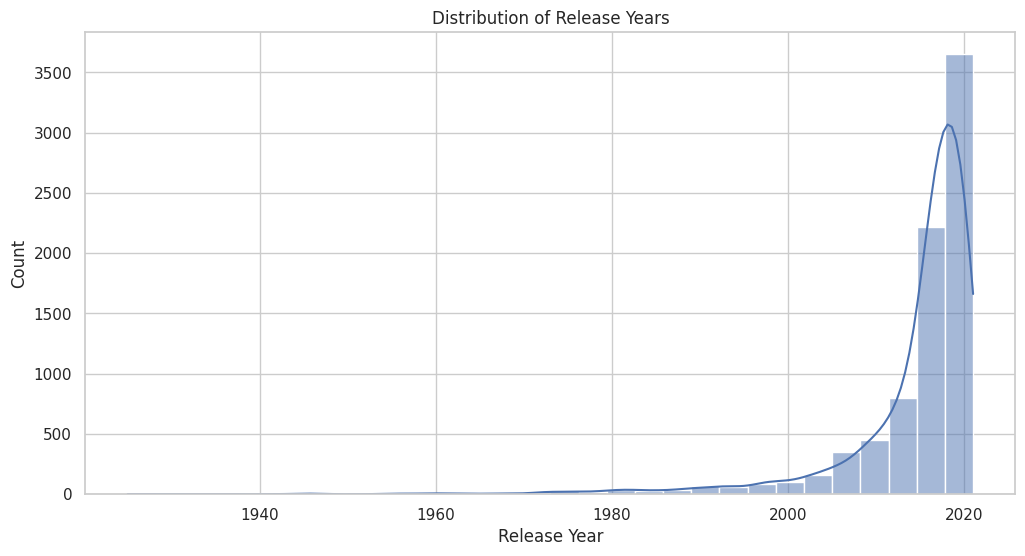

In [48]:
plt.figure(figsize=(12,6))

sns.histplot(df['release_year'],
             bins=30,
             kde=True)

plt.title('Distribution of Release Years')

plt.xlabel('Release Year')

plt.ylabel('Count')

plt.show()

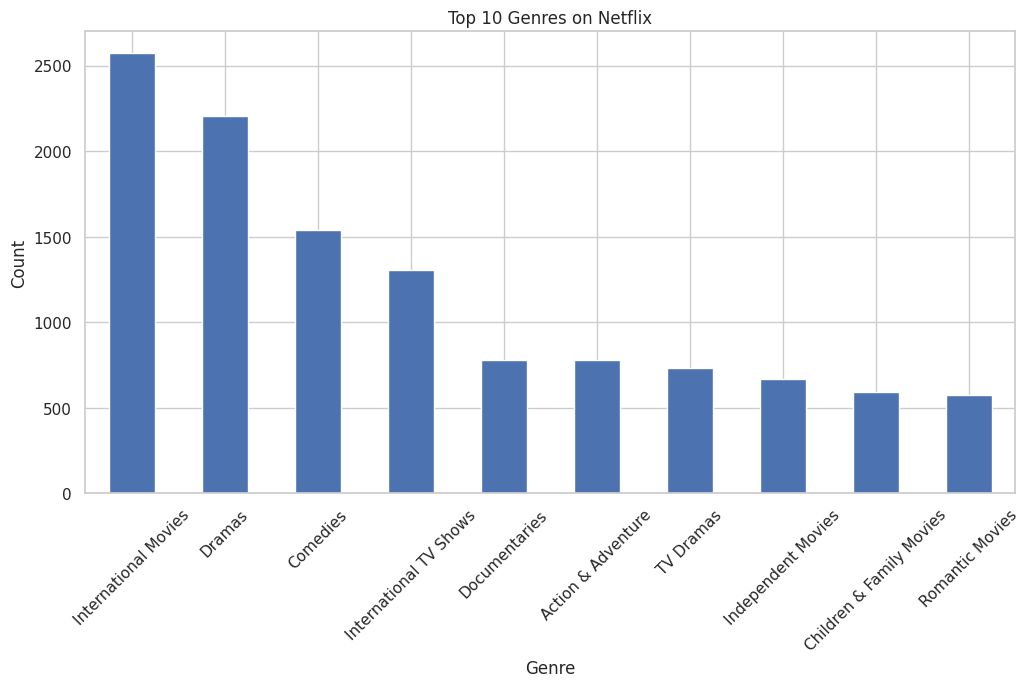

In [49]:
top_genres = df['genre'].str.split(',').explode().str.strip()

plt.figure(figsize=(12,6))

top_genres.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Genres on Netflix')

plt.xlabel('Genre')

plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

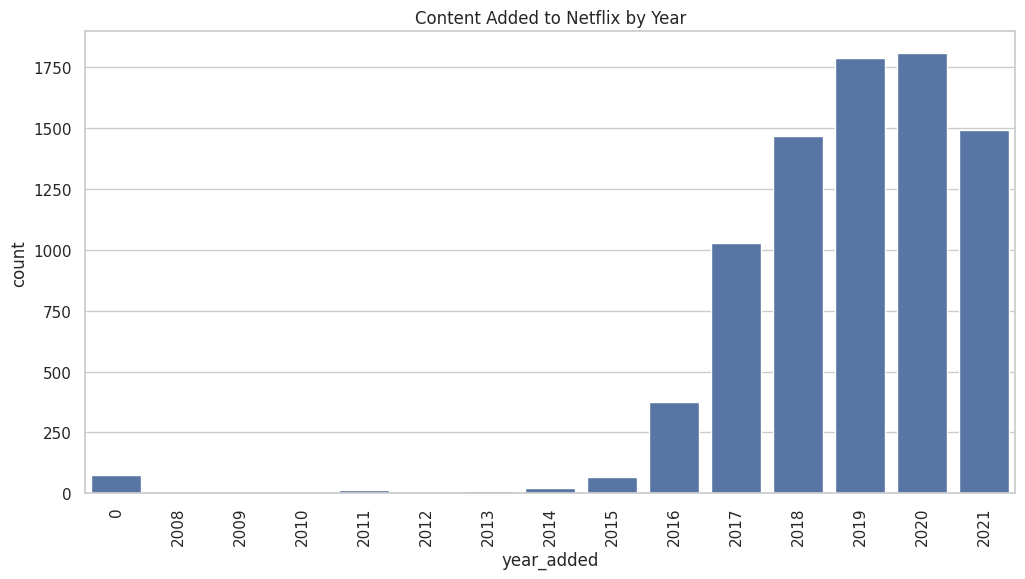

In [50]:
plt.figure(figsize=(12,6))

sns.countplot(x='year_added',
              data=df,
              order=sorted(df['year_added'].unique()))

plt.xticks(rotation=90)

plt.title('Content Added to Netflix by Year')

plt.show()

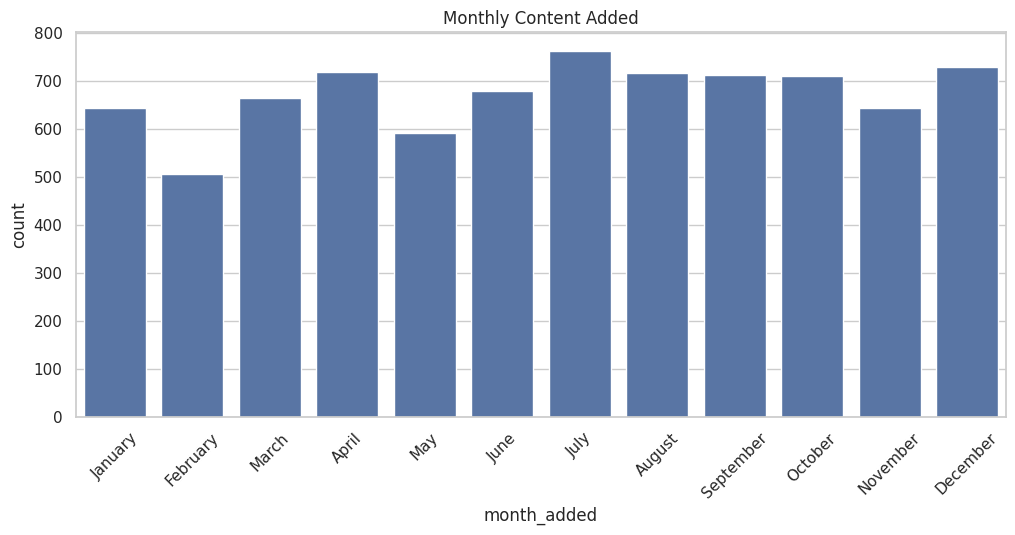

In [51]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

plt.figure(figsize=(12,5))

sns.countplot(
    x='month_added',
    data=df,
    order=month_order
)

plt.xticks(rotation=45)

plt.title('Monthly Content Added')

plt.show()

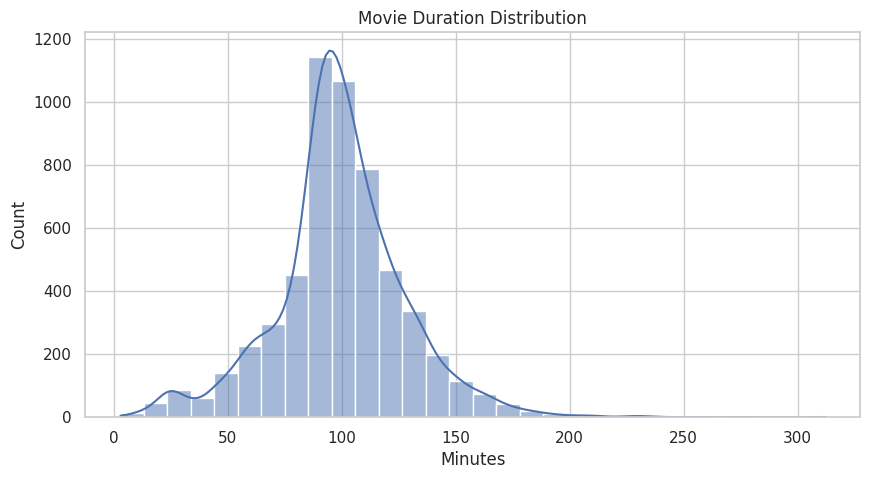

In [52]:
movies = df[df['type']=='Movie']

plt.figure(figsize=(10,5))

sns.histplot(
    movies['duration_num'],
    bins=30,
    kde=True
)

plt.title('Movie Duration Distribution')

plt.xlabel('Minutes')

plt.show()

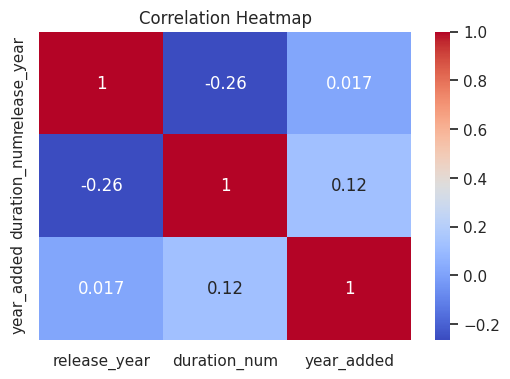

In [53]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['release_year','duration_num','year_added']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

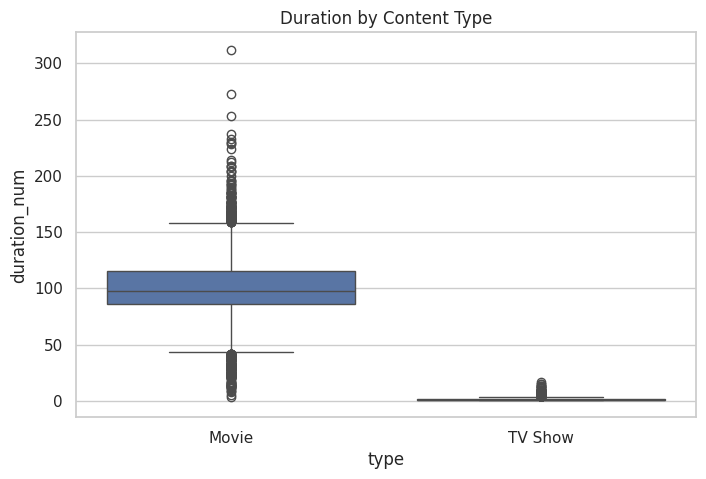

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='type',
    y='duration_num',
    data=df
)

plt.title('Duration by Content Type')

plt.show()

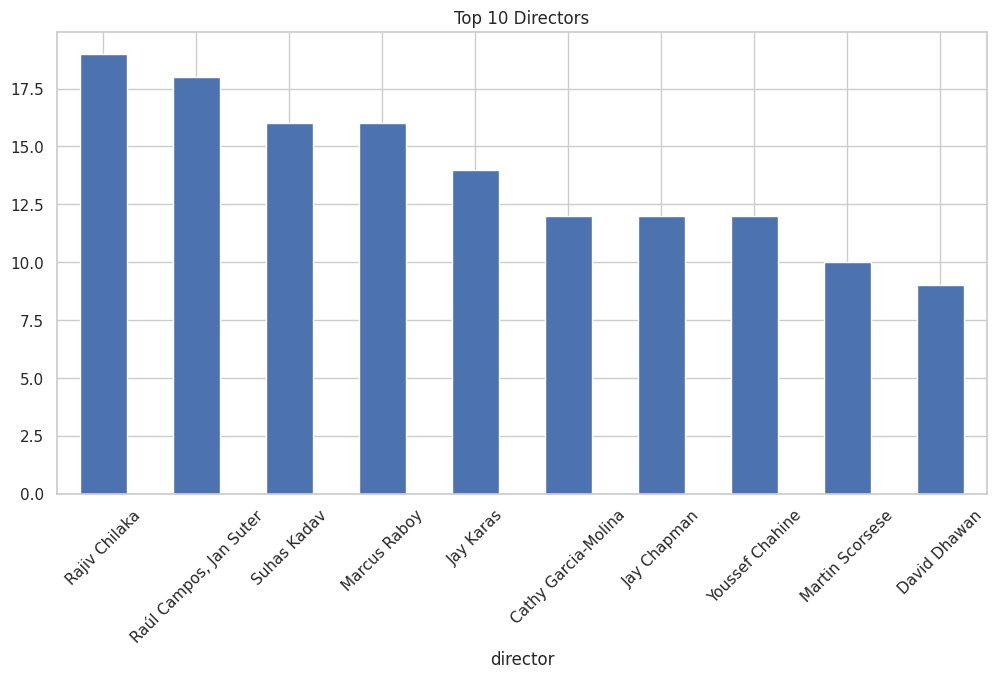

In [55]:
top_directors = df[df['director']!='Unknown']['director']

plt.figure(figsize=(12,6))

top_directors.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Directors')

plt.xticks(rotation=45)

plt.show()

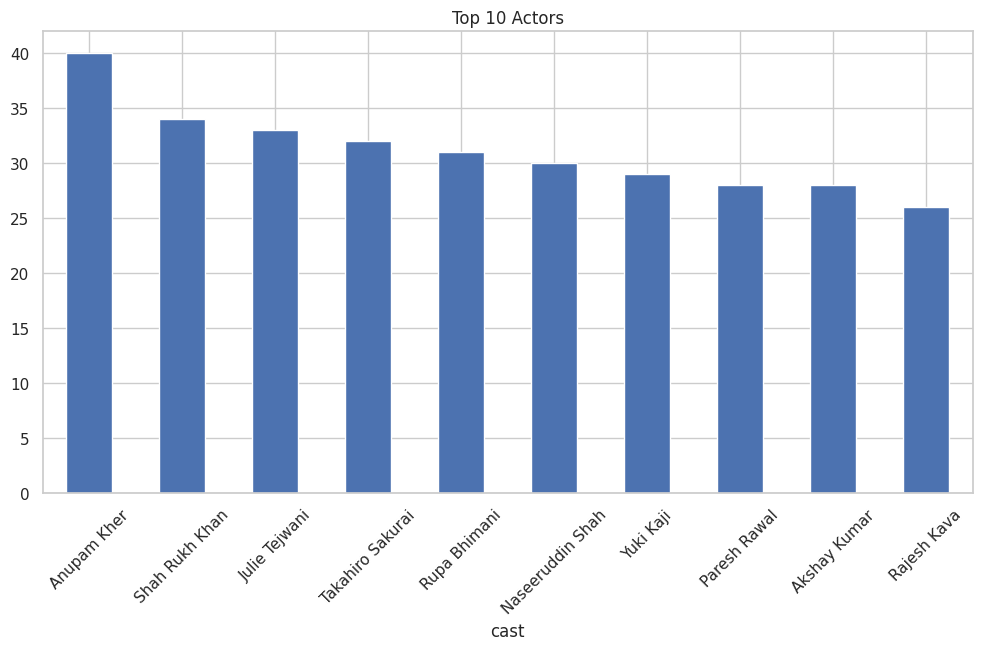

In [56]:
top_cast = (
    df['cast']
    .str.split(',')
    .explode()
    .str.strip()
)

top_cast = top_cast[top_cast != 'Not Available']

plt.figure(figsize=(12,6))

top_cast.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Actors')

plt.xticks(rotation=45)

plt.show()

#Exploratory Data Analysis - Key Insights

##Insight 1

Most of the content available on Netflix consists of Movies rather than TV Shows.

##Insight 2

The United States contributes the highest number of titles on Netflix.

##Insight 3

TV-MA and TV-14 are the most common content ratings.

##Insight 4

The majority of Netflix content was released after 2010.

##Insight 5

International Movies and Dramas are among the most popular genres.

##Insight 6

Netflix experienced rapid growth in content additions between 2018 and 2020.

##Insight 7

Most movies have a duration between 80 and 120 minutes.

##Insight 8

A small number of directors and actors appear repeatedly across multiple titles.

##Insight 9

There is only a weak correlation between release year, duration, and year added.

##Insight 10

The dataset required cleaning due to missing values and inconsistent formats before analysis.

#Conclusion

####This Exploratory Data Analysis project provided valuable insights into the Netflix dataset. The data was cleaned by handling missing values, removing unnecessary columns, converting data types, and creating additional features. Various visualizations helped identify trends in content type, release year, genres, countries, ratings, and duration. Overall, the project demonstrates how EDA can transform raw data into meaningful business insights and support better decision-making.